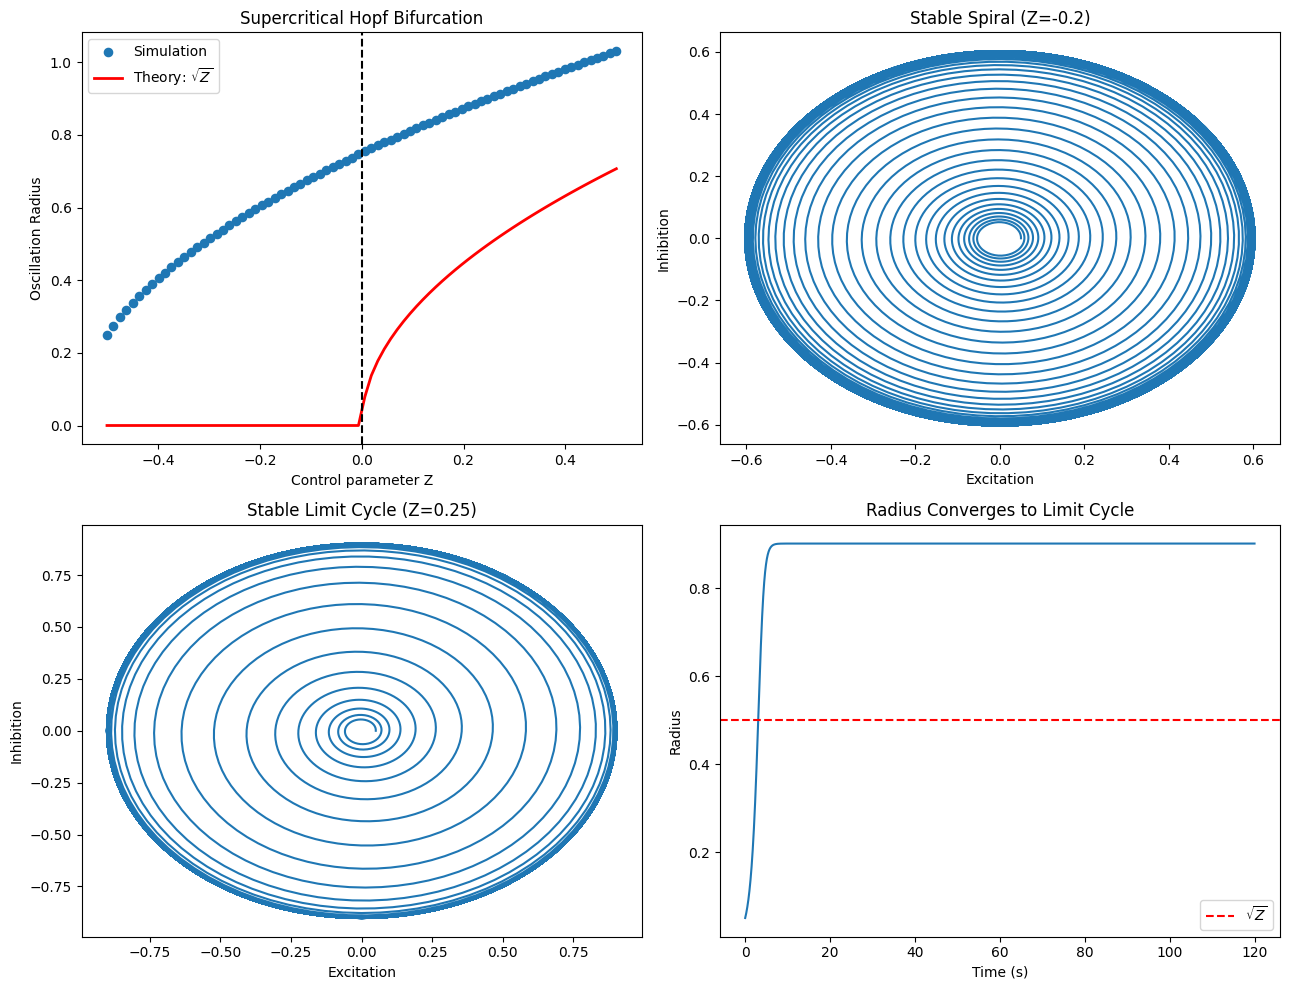

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# =====================================================
# Supercritical Hopf Bifurcation
# True Parameter Sweep
# =====================================================

dt = 0.005
T = 120.0
steps = int(T/dt)

omega = 15.0

# No noise initially.
# We want to compare directly with theory.
noise = 0.0

# Sweep parameter
Z_values = np.linspace(-0.5,0.5,80)

measured_amp = []
theoretical_amp = []

# -----------------------------------------------------
# Sweep through parameter values
# -----------------------------------------------------

for Z in Z_values:

    E = np.zeros(steps)
    I = np.zeros(steps)

    # small perturbation away from equilibrium
    E[0] = 0.01
    I[0] = 0.00

    # Euler integration

    for t in range(steps-1):

        r2 = E[t]**2 + I[t]**2

        dE = Z*E[t] - omega*I[t] - E[t]*r2
        dI = omega*E[t] + Z*I[t] - I[t]*r2

        E[t+1] = E[t] + dE*dt + noise*np.sqrt(dt)*np.random.randn()
        I[t+1] = I[t] + dI*dt + noise*np.sqrt(dt)*np.random.randn()

    # -------------------------------------------------
    # Remove transient
    # -------------------------------------------------

    transient = int(0.6*steps)

    E_ss = E[transient:]
    I_ss = I[transient:]

    radius = np.sqrt(E_ss**2 + I_ss**2)

    # numerical amplitude
    amp = np.mean(radius)

    measured_amp.append(amp)

    # theoretical prediction

    if Z <= 0:
        theoretical_amp.append(0)

    else:
        theoretical_amp.append(np.sqrt(Z))

# =====================================================
# Example trajectory just below Hopf
# =====================================================

Z_demo1 = -0.2

E = np.zeros(steps)
I = np.zeros(steps)

E[0]=0.05

for t in range(steps-1):

    r2 = E[t]**2 + I[t]**2

    dE = Z_demo1*E[t] - omega*I[t] - E[t]*r2
    dI = omega*E[t] + Z_demo1*I[t] - I[t]*r2

    E[t+1]=E[t]+dE*dt
    I[t+1]=I[t]+dI*dt

phase1=(E,I)

# =====================================================
# Example trajectory above Hopf
# =====================================================

Z_demo2 = 0.25

E = np.zeros(steps)
I = np.zeros(steps)

E[0]=0.05

for t in range(steps-1):

    r2 = E[t]**2 + I[t]**2

    dE = Z_demo2*E[t] - omega*I[t] - E[t]*r2
    dI = omega*E[t] + Z_demo2*I[t] - I[t]*r2

    E[t+1]=E[t]+dE*dt
    I[t+1]=I[t]+dI*dt

phase2=(E,I)

# =====================================================
# Plotting
# =====================================================

fig,axs=plt.subplots(2,2,figsize=(13,10))

# ----------------------------
# True bifurcation diagram
# ----------------------------

axs[0,0].scatter(Z_values,
                 measured_amp,
                 s=35,
                 label="Simulation")

axs[0,0].plot(Z_values,
              theoretical_amp,
              color="red",
              linewidth=2,
              label=r"Theory: $\sqrt{Z}$")

axs[0,0].axvline(0,
                 color="black",
                 linestyle="--")

axs[0,0].set_title("Supercritical Hopf Bifurcation")
axs[0,0].set_xlabel("Control parameter Z")
axs[0,0].set_ylabel("Oscillation Radius")
axs[0,0].legend()

# ----------------------------
# Phase portrait below Hopf
# ----------------------------

axs[0,1].plot(phase1[0],phase1[1])

axs[0,1].set_title("Stable Spiral (Z=-0.2)")
axs[0,1].set_xlabel("Excitation")
axs[0,1].set_ylabel("Inhibition")

# ----------------------------
# Phase portrait above Hopf
# ----------------------------

axs[1,0].plot(phase2[0],phase2[1])

axs[1,0].set_title("Stable Limit Cycle (Z=0.25)")
axs[1,0].set_xlabel("Excitation")
axs[1,0].set_ylabel("Inhibition")

# ----------------------------
# Radius evolution
# ----------------------------

radius=np.sqrt(phase2[0]**2+phase2[1]**2)

time=np.arange(len(radius))*dt

axs[1,1].plot(time,radius)

axs[1,1].axhline(np.sqrt(Z_demo2),
                 color='red',
                 linestyle='--',
                 label=r'$\sqrt{Z}$')

axs[1,1].set_title("Radius Converges to Limit Cycle")
axs[1,1].set_xlabel("Time (s)")
axs[1,1].set_ylabel("Radius")
axs[1,1].legend()

plt.tight_layout()
plt.show()